# Problem 1

In [49]:
import numpy as np
import pandas as pd

data = pd.read_csv("spambase.data", header=None)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

print("Dataset loaded successfully.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 labels:", y[:5])

Dataset loaded successfully.
Shape of X: (4601, 57)
Shape of y: (4601,)
First 5 labels: [1 1 1 1 1]


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3220, 57)
Testing set shape: (1381, 57)


In [51]:
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

tree_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [52]:
y_train_pred = tree_entropy.predict(X_train)
y_test_pred = tree_entropy.predict(X_test)

# For AUC, use predicted probabilities for class 1
y_train_prob = tree_entropy.predict_proba(X_train)[:, 1]
y_test_prob = tree_entropy.predict_proba(X_test)[:, 1]

In [53]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_error = 1 - train_accuracy
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_error = 1 - test_accuracy
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Decision Tree using Information Gain (Entropy)")
print("\nTraining Metrics:")
print("Training Error:", round(train_error, 4))
print("Training Accuracy:", round(train_accuracy, 4))
print("Training F1 Score:", round(train_f1, 4))
print("Training AUC:", round(train_auc, 4))

print("\nTesting Metrics:")
print("Testing Error:", round(test_error, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Testing F1 Score:", round(test_f1, 4))
print("Testing AUC:", round(test_auc, 4))

Decision Tree using Information Gain (Entropy)

Training Metrics:
Training Error: 0.0003
Training Accuracy: 0.9997
Training F1 Score: 0.9996
Training AUC: 1.0

Testing Metrics:
Testing Error: 0.0717
Testing Accuracy: 0.9283
Testing F1 Score: 0.9086
Testing AUC: 0.9241


# Problem 2

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [55]:
T_values = [10, 50, 100, 500]

results = []

for T in T_values:
    rf = RandomForestClassifier(
        n_estimators=T,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    results.append({
        "T": T,
        "Train Accuracy": train_acc,
        "Train F1": train_f1,
        "Train AUC": train_auc,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
        "Test AUC": test_auc
    })

In [56]:
for r in results:
    print(f"\nRandom Forest with T = {r['T']} trees")
    
    print("Training:")
    print("Accuracy:", round(r["Train Accuracy"], 4))
    print("F1 Score:", round(r["Train F1"], 4))
    print("AUC:", round(r["Train AUC"], 4))
    
    print("Testing:")
    print("Accuracy:", round(r["Test Accuracy"], 4))
    print("F1 Score:", round(r["Test F1"], 4))
    print("AUC:", round(r["Test AUC"], 4))


Random Forest with T = 10 trees
Training:
Accuracy: 0.996
F1 Score: 0.9949
AUC: 0.9998
Testing:
Accuracy: 0.9442
F1 Score: 0.927
AUC: 0.9812

Random Forest with T = 50 trees
Training:
Accuracy: 0.9991
F1 Score: 0.9988
AUC: 1.0
Testing:
Accuracy: 0.9544
F1 Score: 0.9411
AUC: 0.9849

Random Forest with T = 100 trees
Training:
Accuracy: 0.9997
F1 Score: 0.9996
AUC: 1.0
Testing:
Accuracy: 0.9558
F1 Score: 0.943
AUC: 0.9859

Random Forest with T = 500 trees
Training:
Accuracy: 0.9997
F1 Score: 0.9996
AUC: 1.0
Testing:
Accuracy: 0.9566
F1 Score: 0.9439
AUC: 0.9863


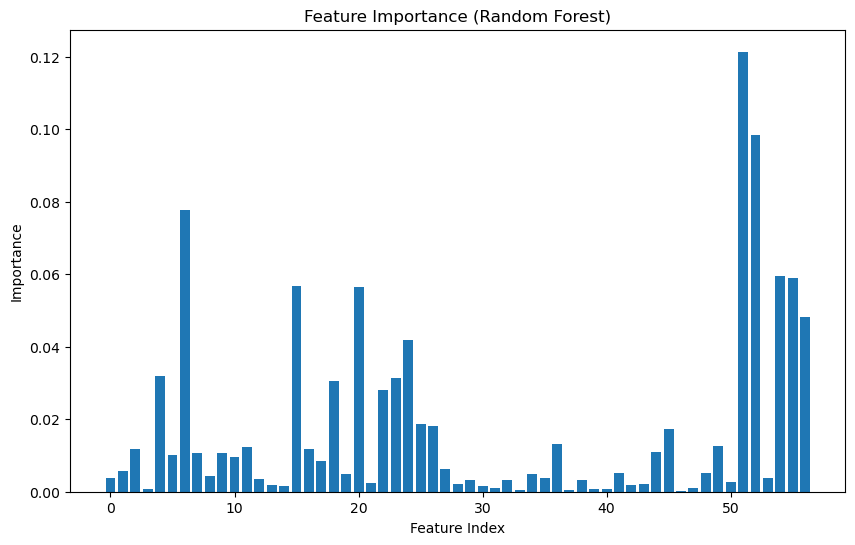

In [57]:
import matplotlib.pyplot as plt
import numpy as np

rf_final = RandomForestClassifier(n_estimators=500, random_state=42)
rf_final.fit(X_train, y_train)

importances = rf_final.feature_importances_

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# Problem 3

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

In [59]:
data = pd.read_csv("spambase.data", header=None)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3220, 57)
Testing set shape: (1381, 57)


In [61]:
T_values = [10, 50, 100, 500]
adaboost_results = []

for T in T_values:
    base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)

    ada_model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=T,
        random_state=42
    )

    ada_model.fit(X_train, y_train)

    # Predictions
    y_train_pred = ada_model.predict(X_train)
    y_test_pred = ada_model.predict(X_test)

    # Probabilities for AUC / ROC
    y_train_prob = ada_model.predict_proba(X_train)[:, 1]
    y_test_prob = ada_model.predict_proba(X_test)[:, 1]

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    adaboost_results.append({
        "T": T,
        "Train Accuracy": train_acc,
        "Train F1": train_f1,
        "Train AUC": train_auc,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
        "Test AUC": test_auc
    })

In [62]:
for r in adaboost_results:
    print(f"\nAdaBoost with T = {r['T']} base classifiers")
    print("Training:")
    print("Accuracy:", round(r["Train Accuracy"], 4))
    print("F1 Score:", round(r["Train F1"], 4))
    print("AUC:", round(r["Train AUC"], 4))

    print("Testing:")
    print("Accuracy:", round(r["Test Accuracy"], 4))
    print("F1 Score:", round(r["Test F1"], 4))
    print("AUC:", round(r["Test AUC"], 4))


AdaBoost with T = 10 base classifiers
Training:
Accuracy: 0.918
F1 Score: 0.893
AUC: 0.9723
Testing:
Accuracy: 0.9066
F1 Score: 0.878
AUC: 0.9698

AdaBoost with T = 50 base classifiers
Training:
Accuracy: 0.9516
F1 Score: 0.9382
AUC: 0.9902
Testing:
Accuracy: 0.9385
F1 Score: 0.9214
AUC: 0.9811

AdaBoost with T = 100 base classifiers
Training:
Accuracy: 0.9624
F1 Score: 0.9523
AUC: 0.9947
Testing:
Accuracy: 0.9377
F1 Score: 0.921
AUC: 0.9782

AdaBoost with T = 500 base classifiers
Training:
Accuracy: 0.9925
F1 Score: 0.9905
AUC: 0.9998
Testing:
Accuracy: 0.9392
F1 Score: 0.9239
AUC: 0.9766


In [63]:
rf_results = []

for T in T_values:
    rf_model = RandomForestClassifier(
        n_estimators=T,
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    # Predictions
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    # Probabilities
    y_train_prob = rf_model.predict_proba(X_train)[:, 1]
    y_test_prob = rf_model.predict_proba(X_test)[:, 1]

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    rf_results.append({
        "T": T,
        "Train Accuracy": train_acc,
        "Train F1": train_f1,
        "Train AUC": train_auc,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
        "Test AUC": test_auc
    })

In [64]:
comparison_rows = []

for i in range(len(T_values)):
    T = T_values[i]

    comparison_rows.append({
        "Model": "Random Forest",
        "T": T,
        "Train Accuracy": rf_results[i]["Train Accuracy"],
        "Train F1": rf_results[i]["Train F1"],
        "Train AUC": rf_results[i]["Train AUC"],
        "Test Accuracy": rf_results[i]["Test Accuracy"],
        "Test F1": rf_results[i]["Test F1"],
        "Test AUC": rf_results[i]["Test AUC"]
    })

    comparison_rows.append({
        "Model": "AdaBoost",
        "T": T,
        "Train Accuracy": adaboost_results[i]["Train Accuracy"],
        "Train F1": adaboost_results[i]["Train F1"],
        "Train AUC": adaboost_results[i]["Train AUC"],
        "Test Accuracy": adaboost_results[i]["Test Accuracy"],
        "Test F1": adaboost_results[i]["Test F1"],
        "Test AUC": adaboost_results[i]["Test AUC"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(4)

,Model,T,Train Accuracy,Train F1,Train AUC,Test Accuracy,Test F1,Test AUC
0,Random Forest,10,0.9960,0.9949,0.9998,0.9442,0.9270,0.9812
1,AdaBoost,10,0.9180,0.8930,0.9723,0.9066,0.8780,0.9698
2,Random Forest,50,0.9991,0.9988,1.0000,0.9544,0.9411,0.9849
3,AdaBoost,50,0.9516,0.9382,0.9902,0.9385,0.9214,0.9811
4,Random Forest,100,0.9997,0.9996,1.0000,0.9558,0.9430,0.9859
5,AdaBoost,100,0.9624,0.9523,0.9947,0.9377,0.9210,0.9782
6,Random Forest,500,0.9997,0.9996,1.0000,0.9566,0.9439,0.9863
7,AdaBoost,500,0.9925,0.9905,0.9998,0.9392,0.9239,0.9766


In [65]:
# Decision Tree model from Problem 1
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt_model.fit(X_train, y_train)

# Random Forest with 100 trees
rf_100 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_100.fit(X_train, y_train)

# AdaBoost with 100 base classifiers
ada_100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
ada_100.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=100, random_state=42)

In [66]:
# Get probabilities for ROC curves
dt_prob = dt_model.predict_proba(X_test)[:, 1]
rf_prob = rf_100.predict_proba(X_test)[:, 1]
ada_prob = ada_100.predict_proba(X_test)[:, 1]

# Compute ROC curve points
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

# Compute AUC values
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
ada_auc = auc(ada_fpr, ada_tpr)

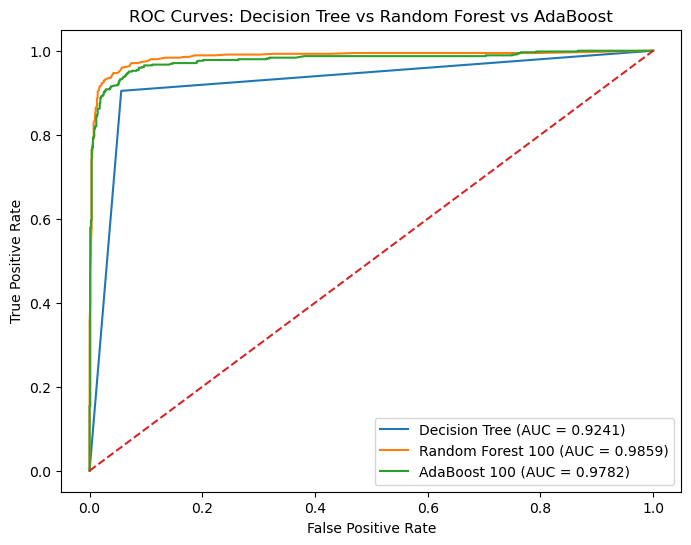

In [67]:
plt.figure(figsize=(8, 6))

plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.4f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest 100 (AUC = {rf_auc:.4f})")
plt.plot(ada_fpr, ada_tpr, label=f"AdaBoost 100 (AUC = {ada_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Decision Tree vs Random Forest vs AdaBoost")
plt.legend()
plt.show()

# Problem 4

In [68]:
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [71]:
data = pd.read_csv("agaricus-lepiota.data", header=None)

y = data.iloc[:, 0]
X = data.iloc[:, 1:]

print(data.shape)
data.head()

Dataset shape: (8124, 23)


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (6093, 22)
Testing set shape: (2031, 22)


In [73]:
class MyNaiveBayes:
    def __init__(self):
        self.class_priors = {}
        self.feature_probs = {}
        self.classes = None
        self.feature_values = {}
    
    def fit(self, X, y):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
        
        self.classes = sorted(y.unique())
        n_samples = len(y)
        n_features = X.shape[1]
        
        for j in range(n_features):
            self.feature_values[j] = sorted(X.iloc[:, j].unique())
        
        for c in self.classes:
            self.class_priors[c] = np.sum(y == c) / n_samples
        
        self.feature_probs = {c: {} for c in self.classes}
        
        for c in self.classes:
            X_c = X[y == c]
            
            for j in range(n_features):
                self.feature_probs[c][j] = {}
                possible_values = self.feature_values[j]
                num_possible_values = len(possible_values)
                
                for value in possible_values:
                    count = np.sum(X_c.iloc[:, j] == value)
                    total = len(X_c)
                    
                    # Laplace smoothing
                    prob = (count + 1) / (total + num_possible_values)
                    self.feature_probs[c][j][value] = prob
    
    def predict_proba_one(self, x):
        class_scores = {}
        
        for c in self.classes:
            log_prob = np.log(self.class_priors[c])
            
            for j, value in enumerate(x):
                if value in self.feature_probs[c][j]:
                    log_prob += np.log(self.feature_probs[c][j][value])
                else:
                    num_possible_values = len(self.feature_values[j])
                    class_count = 1  
                    log_prob += np.log(1 / (class_count + num_possible_values))
            
            class_scores[c] = log_prob
        
        # Convert log scores into normalized probabilities
        max_log = max(class_scores.values())
        exp_scores = {c: np.exp(score - max_log) for c, score in class_scores.items()}
        total = sum(exp_scores.values())
        
        probs = {c: exp_scores[c] / total for c in self.classes}
        return probs
    
    def predict(self, X):
        predictions = []
        
        for i in range(len(X)):
            probs = self.predict_proba_one(X.iloc[i, :].values)
            pred_class = max(probs, key=probs.get)
            predictions.append(pred_class)
        
        return np.array(predictions)
    
    def predict_proba(self, X):
        prob_list = []
        
        for i in range(len(X)):
            probs = self.predict_proba_one(X.iloc[i, :].values)
            prob_list.append([probs[c] for c in self.classes])
        
        return np.array(prob_list)

In [74]:
my_nb = MyNaiveBayes()
my_nb.fit(X_train, y_train)

print("Prior probabilities:")
for c, p in my_nb.class_priors.items():
    print(f"P(Y={c}) = {p:.4f}")

Prior probabilities:
P(Y=e) = 0.5180
P(Y=p) = 0.4820


In [75]:
print("Example conditional probabilities for Feature 0:")
for c in my_nb.classes:
    print(f"\nClass {c}:")
    for value, prob in my_nb.feature_probs[c][0].items():
        print(f"P(X0={value} | Y={c}) = {prob:.4f}")

Example conditional probabilities for Feature 0:

Class e:
P(X0=b | Y=e) = 0.0936
P(X0=c | Y=e) = 0.0003
P(X0=f | Y=e) = 0.3751
P(X0=k | Y=e) = 0.0547
P(X0=s | Y=e) = 0.0079
P(X0=x | Y=e) = 0.4684

Class p:
P(X0=b | Y=p) = 0.0129
P(X0=c | Y=p) = 0.0017
P(X0=f | Y=p) = 0.3955
P(X0=k | Y=p) = 0.1485
P(X0=s | Y=p) = 0.0003
P(X0=x | Y=p) = 0.4410


In [76]:
my_probs = my_nb.predict_proba(X_test)
my_preds = my_nb.predict(X_test)

print("First 5 predicted class probabilities:")
print(my_probs[:5])

print("\nFirst 5 predicted classes:")
print(my_preds[:5])

First 5 predicted class probabilities:
[[9.99999964e-01 3.60062906e-08]
 [3.86431592e-10 1.00000000e+00]
 [9.99997017e-01 2.98295874e-06]
 [9.79462382e-01 2.05376176e-02]
 [7.96097671e-13 1.00000000e+00]]

First 5 predicted classes:
['e' 'p' 'e' 'e' 'p']


In [77]:
# Set poisonous = positive class
my_accuracy = accuracy_score(y_test, my_preds)
my_precision = precision_score(y_test, my_preds, pos_label='p')
my_recall = recall_score(y_test, my_preds, pos_label='p')
my_f1 = f1_score(y_test, my_preds, pos_label='p')

print("My Naive Bayes Results:")
print("Accuracy :", round(my_accuracy, 4))
print("Precision:", round(my_precision, 4))
print("Recall   :", round(my_recall, 4))
print("F1 Score :", round(my_f1, 4))

My Naive Bayes Results:
Accuracy : 0.9527
Precision: 0.9911
Recall   : 0.9101
F1 Score : 0.9489


In [78]:
encoder = OrdinalEncoder()

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

y_train_encoded = y_train.map({'e': 0, 'p': 1})
y_test_encoded = y_test.map({'e': 0, 'p': 1})

In [79]:
package_nb = CategoricalNB(alpha=1.0)  # alpha=1 = Laplace smoothing
package_nb.fit(X_train_encoded, y_train_encoded)

package_preds_encoded = package_nb.predict(X_test_encoded)
package_probs = package_nb.predict_proba(X_test_encoded)

package_preds = np.where(package_preds_encoded == 0, 'e', 'p')

print("First 5 package predictions:")
print(package_preds[:5])

First 5 package predictions:
['e' 'p' 'e' 'e' 'p']


In [80]:
package_accuracy = accuracy_score(y_test, package_preds)
package_precision = precision_score(y_test, package_preds, pos_label='p')
package_recall = recall_score(y_test, package_preds, pos_label='p')
package_f1 = f1_score(y_test, package_preds, pos_label='p')

print("Package Naive Bayes Results:")
print("Accuracy :", round(package_accuracy, 4))
print("Precision:", round(package_precision, 4))
print("Recall   :", round(package_recall, 4))
print("F1 Score :", round(package_f1, 4))

Package Naive Bayes Results:
Accuracy : 0.9527
Precision: 0.9911
Recall   : 0.9101
F1 Score : 0.9489


In [83]:
comparison_df = pd.DataFrame({
    "Model": ["My Naive Bayes", "Package Naive Bayes"],
    "Accuracy": [my_accuracy, package_accuracy],
    "Precision": [my_precision, package_precision],
    "Recall": [my_recall, package_recall],
    "F1 Score": [my_f1, package_f1]
})

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,My Naive Bayes,0.9527,0.9911,0.9101,0.9489
1,Package Naive Bayes,0.9527,0.9911,0.9101,0.9489


In [84]:
print("My Naive Bayes:")
print(f"Accuracy = {my_accuracy:.4f}")
print(f"Precision = {my_precision:.4f}")
print(f"Recall = {my_recall:.4f}")
print(f"F1 Score = {my_f1:.4f}")

print("\nPackage Naive Bayes:")
print(f"Accuracy = {package_accuracy:.4f}")
print(f"Precision = {package_precision:.4f}")
print(f"Recall = {package_recall:.4f}")
print(f"F1 Score = {package_f1:.4f}")

My Naive Bayes:
Accuracy = 0.9527
Precision = 0.9911
Recall = 0.9101
F1 Score = 0.9489

Package Naive Bayes:
Accuracy = 0.9527
Precision = 0.9911
Recall = 0.9101
F1 Score = 0.9489
